Kaggle Dataset Download

In [ ]:
import os

# 1. Setup API Key
os.environ["KAGGLE_USERNAME"] = "muhammadaliffandy"
os.environ["KAGGLE_KEY"] = "KGAT_6cf20e173408038efc8c307643a53392"

# 2. Install kagglehub
!pip install -q kagglehub

import kagglehub

print("⏳ Memulai download dataset BraTS2020...")
# Download (ini akan masuk ke cache dulu)
download_path = kagglehub.dataset_download("andrewmvd/ct-low-dose-reconstruction")

print(f"✅ Download selesai di: {download_path}")

# 3. Pindahkan secara paksa menggunakan perintah terminal (Linux cp)
# Kita pakai -r (recursive) untuk copy folder dan isinya
print("🚚 Memindahkan folder ke /content agar lebih mudah diakses...")

!cp -r "{download_path}" /content/




⏳ Memulai download dataset BraTS2020...


100%|██████████| 18.3G/18.3G [03:45<00:00, 87.4MB/s]


Extracting files...
✅ Download selesai di: /root/.cache/kagglehub/datasets/andrewmvd/ct-low-dose-reconstruction/versions/2
🚚 Memindahkan folder ke /content agar lebih mudah diakses...


Training Preparation

🔍 Checking CUDA / GPU Availability...
✅ GPU Detected: /physical_device:GPU:0
--- Loading dataset using Kaggle structure from: /content/Dataset/Preprocessed_256x256/256 ---
🔍 Scanning directories for image files...
📦 Found 16628 Full Dose (Label 0) and 16628 Quarter Dose (Label 1) images.
🚀 Processing Full Dose (Normal) images (Limit: 500)...
🚀 Processing Quarter Dose (Low Dose) images (Limit: 500)...
✅ Data loading complete! Total images loaded: 1000

🔀 Shuffling dataset to prevent ordering bias...

--- Stage 1: Fitting Scaler and UMAP ---
✅ Scaler saved.
✅ UMAP saved.

--- Stage 2: Training Keras Hybrid Model on GPU ---
--- Building Hybrid Keras Architecture ---
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.8132 - loss: 2.4589 - val_accuracy: 1.0000 - val_loss: 0.0297
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - accuracy: 1.0000 - loss: 0.0161 - val_accuracy: 1.0000 - val_loss: 0.0024
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 1.0000 - lo

✅ Keras model saved to ./new_model/best_model.h5.

--- Stage 3: Extracting Deep Features for LightGBM Agent ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
Extracted Agent Features Shape: (1000, 355)

--- Stage 4: Data Splitting & Training LightGBM Agent ---
Training samples: 800 | Testing samples: 200
✅ LightGBM Agent saved to ./new_model/agent_deep_verified.txt.

--- Stage 5: Evaluating Model on Test Data ---

 🎯 AGENT TEST ACCURACY: 100.00%

Classification Report (Test Data):
              precision    recall  f1-score   support

   Full_Dose       1.00      1.00      1.00       100
Quarter_Dose       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



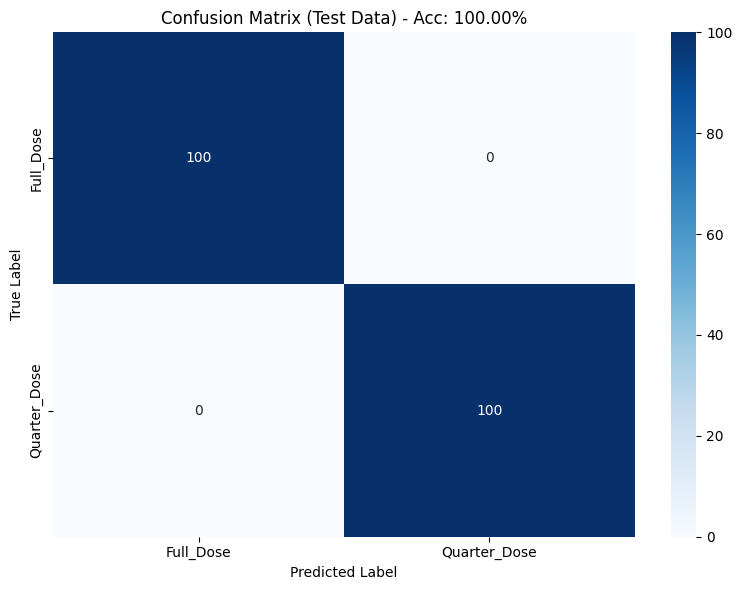

✅ Confusion Matrix plot saved to ./new_model/confusion_matrix.png.

🎉 ALL TRAINING PIPELINES COMPLETED SUCCESSFULLY! 🎉


In [ ]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import pywt
import scipy.stats
import warnings
import glob
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.utils import to_categorical
from umap import UMAP

# --- CONFIGURATIONS & CUDA SETUP ---
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("🔍 Checking CUDA / GPU Availability...")
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"✅ GPU Detected: {physical_devices[0].name}")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("⚠️ WARNING: No GPU detected. Training will fall back to CPU and might be slow.")

IMG_SIZE = (256, 256)
WAVELET = 'db1'
CLASS_NAMES = ['Full_Dose', 'Quarter_Dose']
NUM_CLASSES = len(CLASS_NAMES)
SAVE_DIR = "./new_model"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

PATHS = {
    "keras": os.path.join(SAVE_DIR, "best_model.h5"),
    "scaler": os.path.join(SAVE_DIR, "scaler_final.pkl"),
    "umap": os.path.join(SAVE_DIR, "umap_final.pkl"),
    "agent": os.path.join(SAVE_DIR, "agent_deep_verified.txt"),
    "confusion_matrix": os.path.join(SAVE_DIR, "confusion_matrix.png")
}

# ==============================================================================
# 1. FEATURE EXTRACTION FUNCTIONS
# ==============================================================================
def extract_handcrafted(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img

    coeffs = pywt.dwt2(gray, WAVELET)
    LL, (LH, HL, HH) = coeffs

    def _stats(band):
        flat = np.abs(band.flatten()) + 1e-6
        return [np.mean(band), np.std(band), np.var(band), scipy.stats.entropy(flat)]

    feats = []
    for band in [LL, LH, HL, HH]: feats.extend(_stats(band))
    feats.append(np.sum(np.square(HH)))

    gray_norm = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    from skimage.feature import graycomatrix, graycoprops
    glcm = graycomatrix(gray_norm, [5], [0, np.pi/4, np.pi/2], 256, symmetric=True, normed=True)
    feats.extend([graycoprops(glcm, 'contrast').mean(),
                  graycoprops(glcm, 'dissimilarity').mean(),
                  graycoprops(glcm, 'homogeneity').mean()])
    return feats

# ==============================================================================
# 2. DATA LOADING (KAGGLE GLOB DIRECTORY METHOD)
# ==============================================================================
def load_dataset(base_dir):
    print(f"--- Loading dataset using Kaggle structure from: {base_dir} ---")

    ld_dir = os.path.join(base_dir, "Quarter Dose")
    nd_dir = os.path.join(base_dir, "Full Dose")

    if not os.path.exists(ld_dir) or not os.path.exists(nd_dir):
        print(f"❌ Error: 'Quarter Dose' or 'Full Dose' folders not found inside {base_dir}!")
        return None, None, None

    exts = ("*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff", "*.bmp", "*.npy")
    ld_files, nd_files = [], []

    print("🔍 Scanning directories for image files...")
    for ext in exts:
        ld_files.extend(glob.glob(os.path.join(ld_dir, "**", ext), recursive=True))
        nd_files.extend(glob.glob(os.path.join(nd_dir, "**", ext), recursive=True))

    ld_files, nd_files = sorted(ld_files), sorted(nd_files)
    print(f"📦 Found {len(nd_files)} Full Dose (Label 0) and {len(ld_files)} Quarter Dose (Label 1) images.")

    images, handcrafted_feats, labels = [], [], []

    # LIMITER (Keep it at 500 first for safety in Colab)
    LIMIT = 500

    print(f"🚀 Processing Full Dose (Normal) images (Limit: {LIMIT})...")
    for i, file_path in enumerate(nd_files[:LIMIT]):
        raw_img = cv2.imread(file_path)
        if raw_img is not None:
            img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
            norm_img = img_rgb.astype(np.float32) / 255.0
            images.append(norm_img)
            handcrafted_feats.append(extract_handcrafted(img_rgb))
            labels.append(0)

    print(f"🚀 Processing Quarter Dose (Low Dose) images (Limit: {LIMIT})...")
    for i, file_path in enumerate(ld_files[:LIMIT]):
        raw_img = cv2.imread(file_path)
        if raw_img is not None:
            img_rgb = cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)
            norm_img = img_rgb.astype(np.float32) / 255.0
            images.append(norm_img)
            handcrafted_feats.append(extract_handcrafted(img_rgb))
            labels.append(1)

    print(f"✅ Data loading complete! Total images loaded: {len(images)}")
    return np.array(images), np.array(handcrafted_feats), np.array(labels)

# ==============================================================================
# 3. BUILD KERAS HYBRID MODEL
# ==============================================================================
def build_keras_model(hc_dim, umap_dim):
    print("--- Building Hybrid Keras Architecture ---")
    with tf.device('/GPU:0'):
        img_input = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="image_input")
        x = Conv2D(32, (3, 3), activation='relu')(img_input)
        x = MaxPooling2D((2, 2))(x)
        x = Conv2D(64, (3, 3), activation='relu')(x)
        x = MaxPooling2D((2, 2))(x)
        x = Flatten()(x)
        cnn_features = Dense(256, activation='relu')(x)

        hc_input = Input(shape=(hc_dim,), name="hc_input")
        hc_dense = Dense(64, activation='relu')(hc_input)

        umap_input = Input(shape=(umap_dim,), name="umap_input")
        umap_dense = Dense(32, activation='relu')(umap_input)

        merged = Concatenate(name="concatenate_features")([cnn_features, hc_dense, umap_dense])
        output = Dense(NUM_CLASSES, activation='softmax', name="main_output")(merged)

        model = Model(inputs=[img_input, hc_input, umap_input], outputs=output)
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ==============================================================================
# 4. MAIN TRAINING PIPELINE
# ==============================================================================
def train_pipeline(data_dir):
    X_img, X_hc, y_labels = load_dataset(data_dir)
    if X_img is None: return

    # --- SHUFFLE DATA MENCEGAH BIAS URUTAN ---
    print("\n🔀 Shuffling dataset to prevent ordering bias...")
    X_img, X_hc, y_labels = shuffle(X_img, X_hc, y_labels, random_state=42)

    y_cat = to_categorical(y_labels, num_classes=NUM_CLASSES)

    print("\n--- Stage 1: Fitting Scaler and UMAP ---")
    scaler = StandardScaler()
    X_hc_scaled = scaler.fit_transform(X_hc)
    joblib.dump(scaler, PATHS["scaler"])
    print("✅ Scaler saved.")

    umap_model = UMAP(n_components=2, random_state=42)
    X_umap = umap_model.fit_transform(X_hc_scaled)
    joblib.dump(umap_model, PATHS["umap"])
    print("✅ UMAP saved.")

    print("\n--- Stage 2: Training Keras Hybrid Model on GPU ---")
    keras_model = build_keras_model(hc_dim=X_hc.shape[1], umap_dim=X_umap.shape[1])

    with tf.device('/GPU:0'):
        keras_model.fit(
            [X_img, X_hc_scaled, X_umap], y_cat,
            epochs=15,
            batch_size=16,
            validation_split=0.2
        )
    keras_model.save(PATHS["keras"])
    print(f"✅ Keras model saved to {PATHS['keras']}.")

    print("\n--- Stage 3: Extracting Deep Features for LightGBM Agent ---")
    concat_layer = None
    for layer in keras_model.layers:
        if "concatenate" in layer.name:
            concat_layer = layer.name
            break

    with tf.device('/GPU:0'):
        extractor = Model(inputs=keras_model.input, outputs=keras_model.get_layer(concat_layer).output)
        keras_probs = keras_model.predict([X_img, X_hc_scaled, X_umap], batch_size=16)
        deep_features = extractor.predict([X_img, X_hc_scaled, X_umap], batch_size=16)

    entropies = np.array([scipy.stats.entropy(prob) for prob in keras_probs]).reshape(-1, 1)
    X_agent = np.hstack([deep_features, keras_probs, entropies])
    print(f"Extracted Agent Features Shape: {X_agent.shape}")

    print("\n--- Stage 4: Data Splitting & Training LightGBM Agent ---")
    # Split data: 80% for training, 20% for testing the true capability
    X_train, X_test, y_train, y_test = train_test_split(X_agent, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

    print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

    lgb_train = lgb.Dataset(X_train, label=y_train)

    params = {
        'objective': 'multiclass',
        'num_class': NUM_CLASSES,
        'metric': 'multi_logloss',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'device': 'gpu',
        'verbose': -1
    }

    agent_model = lgb.train(params, lgb_train, num_boost_round=100)
    agent_model.save_model(PATHS["agent"])
    print(f"✅ LightGBM Agent saved to {PATHS['agent']}.")

    # ==========================================================================
    # 5. EVALUATION: CONFUSION MATRIX & ACCURACY PERCENTAGE
    # ==========================================================================
    print("\n--- Stage 5: Evaluating Model on Test Data ---")

    # Predict ONLY on the unseen test set
    agent_preds_proba = agent_model.predict(X_test)
    agent_preds = np.argmax(agent_preds_proba, axis=1)

    # Calculate Accuracy Percentage
    accuracy_pct = accuracy_score(y_test, agent_preds) * 100

    print("\n" + "="*50)
    print(f" 🎯 AGENT TEST ACCURACY: {accuracy_pct:.2f}%")
    print("="*50 + "\n")

    # Compute confusion matrix
    cm = confusion_matrix(y_test, agent_preds)

    # Print classification report
    print("Classification Report (Test Data):")
    print(classification_report(y_test, agent_preds, target_names=CLASS_NAMES))

    # Plotting the confusion matrix using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix (Test Data) - Acc: {accuracy_pct:.2f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    # Save and show plot
    plt.tight_layout()
    plt.savefig(PATHS["confusion_matrix"])
    plt.show()
    print(f"✅ Confusion Matrix plot saved to {PATHS['confusion_matrix']}.")

    print("\n🎉 ALL TRAINING PIPELINES COMPLETED SUCCESSFULLY! 🎉")

# --- EXECUTE SCRIPT ---
if __name__ == "__main__":
    BASE_DIRECTORY = "/content/Dataset/Preprocessed_256x256/256"
    train_pipeline(BASE_DIRECTORY)

In [ ]:
import os

def print_directory_tree(startpath, max_files=5):
    print(f"🔍 --- Scanning Directory Tree for: {startpath} --- 🔍\n")

    if not os.path.exists(startpath):
        print(f"❌ Error: The path '{startpath}' does not exist. Please check the spelling.")
        return

    for root, dirs, files in os.walk(startpath):
        # Calculate the depth level for indentation
        level = root.replace(startpath, '').count(os.sep)
        indent = ' ' * 4 * level

        # Print the current folder name
        folder_name = os.path.basename(root)
        if folder_name == '':
            folder_name = startpath
        print(f"{indent}📁 {folder_name}/")

        # Print the files inside this folder (limited to max_files)
        subindent = ' ' * 4 * (level + 1)
        for i, f in enumerate(files):
            if i < max_files:
                print(f"{subindent}📄 {f}")
            elif i == max_files:
                print(f"{subindent}└── ... and {len(files) - max_files} more files")
                break

# --- EXECUTE SCRIPT ---
folder_to_scan = "/content/Dataset"
print_directory_tree(folder_to_scan)

🔍 --- Scanning Directory Tree for: /content/Dataset --- 🔍

📁 Dataset/
    📄 metadata.csv
    📁 Preprocessed_256x256/
        📁 256/
            📁 Full Dose/
                📁 1mm/
                    📁 Sharp Kernel (D45)/
                        📁 L286/
                            📄 L286_FD_1_SHARP_1.CT.0002.0446.2016.01.21.18.19.18.666560.404714452.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0404.2016.01.21.18.19.18.666560.404713444.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0181.2016.01.21.18.19.18.666560.404708092.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0221.2016.01.21.18.19.18.666560.404709052.png
                            📄 L286_FD_1_SHARP_1.CT.0002.0351.2016.01.21.18.19.18.666560.404712172.png
                            └── ... and 520 more files
                        📁 L310/
                            📄 L310_FD_1_SHARP_1.CT.0002.0533.2016.01.21.18.20.47.435560.404621787.png
                            📄 L310_FD_1_SHARP_1

🔍 Checking CUDA / GPU Availability...
✅ GPU Detected: /physical_device:GPU:0
--- Loading DICOM dataset from: /content/Dataset/CT_low_dose_reconstruction_dataset/Original Data ---
🔍 Scanning directories for medical image files (.IMA)...
📦 Found 16628 Full Dose (Label 0) and 16628 Quarter Dose (Label 1) images.
🚀 Processing Full Dose (Normal) images (Limit: 500)...
🚀 Processing Quarter Dose (Low Dose) images (Limit: 500)...
✅ Data loading complete! Total images loaded: 1000

🔀 Shuffling dataset to prevent ordering bias...

--- Stage 1: Fitting Scaler and UMAP ---
✅ Scaler saved.
✅ UMAP saved.

--- Stage 2: Training Keras Hybrid Model on GPU ---
--- Building Hybrid Keras Architecture ---
Epoch 1/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 71ms/step - accuracy: 0.7695 - loss: 1.8333 - val_accuracy: 1.0000 - val_loss: 0.0494
Epoch 2/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 1.0000 - loss: 0.0297 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 3/15
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step -

✅ Keras model saved to ./new_model/best_model.h5.

--- Stage 3: Extracting Deep Features for LightGBM Agent ---
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step
Extracted Agent Features Shape: (1000, 355)

--- Stage 4: Data Splitting & Training LightGBM Agent ---
Training samples: 800 | Testing samples: 200
✅ LightGBM Agent saved to ./new_model/agent_deep_verified.txt.

--- Stage 5: Evaluating Model on Test Data ---

 🎯 AGENT TEST ACCURACY: 100.00%

Classification Report (Test Data):
              precision    recall  f1-score   support

   Full_Dose       1.00      1.00      1.00       100
Quarter_Dose       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



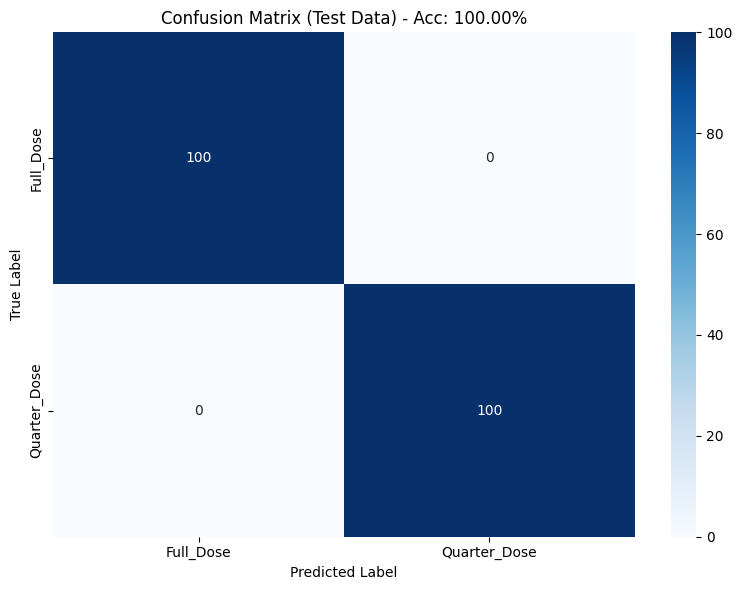

✅ Confusion Matrix plot saved to ./new_model/confusion_matrix.png.

🎉 ALL TRAINING PIPELINES COMPLETED SUCCESSFULLY! 🎉


In [ ]:
import os
import cv2
import joblib
import numpy as np
import pandas as pd
import pywt
import scipy.stats
import warnings
import glob
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Concatenate, Dropout
from tensorflow.keras.utils import to_categorical
from umap import UMAP

# --- CONFIGURATIONS & CUDA SETUP ---
warnings.filterwarnings("ignore")
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

print("🔍 Checking CUDA / GPU Availability...")
physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    print(f"✅ GPU Detected: {physical_devices[0].name}")
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
else:
    print("⚠️ WARNING: No GPU detected. Training will fall back to CPU and might be slow.")

IMG_SIZE = (256, 256)
WAVELET = 'db1'
CLASS_NAMES = ['Full_Dose', 'Quarter_Dose']
NUM_CLASSES = len(CLASS_NAMES)
SAVE_DIR = "./new_model"

if not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR)

PATHS = {
    "keras": os.path.join(SAVE_DIR, "best_model.h5"),
    "scaler": os.path.join(SAVE_DIR, "scaler_final.pkl"),
    "umap": os.path.join(SAVE_DIR, "umap_final.pkl"),
    "agent": os.path.join(SAVE_DIR, "agent_deep_verified.txt"),
    "confusion_matrix": os.path.join(SAVE_DIR, "confusion_matrix.png")
}

# ==============================================================================
# 1. FEATURE EXTRACTION FUNCTIONS
# ==============================================================================
def extract_handcrafted(img):
    if len(img.shape) == 3:
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    else:
        gray = img

    coeffs = pywt.dwt2(gray, WAVELET)
    LL, (LH, HL, HH) = coeffs

    def _stats(band):
        flat = np.abs(band.flatten()) + 1e-6
        return [np.mean(band), np.std(band), np.var(band), scipy.stats.entropy(flat)]

    feats = []
    for band in [LL, LH, HL, HH]: feats.extend(_stats(band))
    feats.append(np.sum(np.square(HH)))

    gray_norm = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    from skimage.feature import graycomatrix, graycoprops
    glcm = graycomatrix(gray_norm, [5], [0, np.pi/4, np.pi/2], 256, symmetric=True, normed=True)
    feats.extend([graycoprops(glcm, 'contrast').mean(),
                  graycoprops(glcm, 'dissimilarity').mean(),
                  graycoprops(glcm, 'homogeneity').mean()])
    return feats

# ==============================================================================
# 2. DATA LOADING (KAGGLE GLOB DIRECTORY METHOD)
# ==============================================================================
import glob
import pydicom

# ==============================================================================
# 2. DATA LOADING (CUSTOMIZED FOR .IMA / DICOM FILES)
# ==============================================================================
def load_dataset(base_dir):
    print(f"--- Loading DICOM dataset from: {base_dir} ---")

    ld_dir = os.path.join(base_dir, "Quarter Dose")
    nd_dir = os.path.join(base_dir, "Full Dose")

    if not os.path.exists(ld_dir) or not os.path.exists(nd_dir):
        print(f"❌ Error: 'Quarter Dose' or 'Full Dose' folders not found inside {base_dir}!")
        return None, None, None

    # Update extensions to look for .IMA or .dcm files
    exts = ("*.IMA", "*.ima", "*.dcm")
    ld_files, nd_files = [], []

    print("🔍 Scanning directories for medical image files (.IMA)...")
    for ext in exts:
        ld_files.extend(glob.glob(os.path.join(ld_dir, "**", ext), recursive=True))
        nd_files.extend(glob.glob(os.path.join(nd_dir, "**", ext), recursive=True))

    ld_files, nd_files = sorted(ld_files), sorted(nd_files)
    print(f"📦 Found {len(nd_files)} Full Dose (Label 0) and {len(ld_files)} Quarter Dose (Label 1) images.")

    images, handcrafted_feats, labels = [], [], []

    # LIMITER (Keep it safe for Colab RAM)
    LIMIT = 500

    # Helper function to process DICOM to RGB numpy array
    def process_dicom(file_path):
        try:
            # Read the DICOM file
            dcm = pydicom.dcmread(file_path)
            img_array = dcm.pixel_array.astype(np.float32)

            # Normalize to 0-255 (DICOM is usually 12-bit or 16-bit)
            img_normalized = (img_array - np.min(img_array)) / (np.max(img_array) - np.min(img_array) + 1e-6) * 255.0
            img_uint8 = img_normalized.astype(np.uint8)

            # Convert 1-channel Grayscale to 3-channel RGB for Keras ResNet/VGG inputs
            img_rgb = cv2.cvtColor(img_uint8, cv2.COLOR_GRAY2RGB)

            # Resize to match our IMG_SIZE (256x256)
            img_resized = cv2.resize(img_rgb, IMG_SIZE)

            return img_resized
        except Exception as e:
            print(f"⚠️ Error reading {file_path}: {e}")
            return None

    print(f"🚀 Processing Full Dose (Normal) images (Limit: {LIMIT})...")
    for i, file_path in enumerate(nd_files[:LIMIT]):
        img_rgb = process_dicom(file_path)
        if img_rgb is not None:
            norm_img = img_rgb.astype(np.float32) / 255.0
            images.append(norm_img)
            handcrafted_feats.append(extract_handcrafted(img_rgb))
            labels.append(0)

    print(f"🚀 Processing Quarter Dose (Low Dose) images (Limit: {LIMIT})...")
    for i, file_path in enumerate(ld_files[:LIMIT]):
        img_rgb = process_dicom(file_path)
        if img_rgb is not None:
            norm_img = img_rgb.astype(np.float32) / 255.0
            images.append(norm_img)
            handcrafted_feats.append(extract_handcrafted(img_rgb))
            labels.append(1)

    print(f"✅ Data loading complete! Total images loaded: {len(images)}")
    return np.array(images), np.array(handcrafted_feats), np.array(labels)

# ==============================================================================
# 3. BUILD KERAS HYBRID MODEL
# ==============================================================================
def build_keras_model(hc_dim, umap_dim):
    print("--- Building Hybrid Keras Architecture ---")
    with tf.device('/GPU:0'):
        img_input = Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="image_input")
        x = Conv2D(32, (3, 3), activation='relu')(img_input)
        x = MaxPooling2D((2, 2))(x)
        x = Conv2D(64, (3, 3), activation='relu')(x)
        x = MaxPooling2D((2, 2))(x)
        x = Flatten()(x)
        cnn_features = Dense(256, activation='relu')(x)

        hc_input = Input(shape=(hc_dim,), name="hc_input")
        hc_dense = Dense(64, activation='relu')(hc_input)

        umap_input = Input(shape=(umap_dim,), name="umap_input")
        umap_dense = Dense(32, activation='relu')(umap_input)

        merged = Concatenate(name="concatenate_features")([cnn_features, hc_dense, umap_dense])
        output = Dense(NUM_CLASSES, activation='softmax', name="main_output")(merged)

        model = Model(inputs=[img_input, hc_input, umap_input], outputs=output)
        model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# ==============================================================================
# 4. MAIN TRAINING PIPELINE
# ==============================================================================
def train_pipeline(data_dir):
    X_img, X_hc, y_labels = load_dataset(data_dir)
    if X_img is None: return

    # --- SHUFFLE DATA MENCEGAH BIAS URUTAN ---
    print("\n🔀 Shuffling dataset to prevent ordering bias...")
    X_img, X_hc, y_labels = shuffle(X_img, X_hc, y_labels, random_state=42)

    y_cat = to_categorical(y_labels, num_classes=NUM_CLASSES)

    print("\n--- Stage 1: Fitting Scaler and UMAP ---")
    scaler = StandardScaler()
    X_hc_scaled = scaler.fit_transform(X_hc)
    joblib.dump(scaler, PATHS["scaler"])
    print("✅ Scaler saved.")

    umap_model = UMAP(n_components=2, random_state=42)
    X_umap = umap_model.fit_transform(X_hc_scaled)
    joblib.dump(umap_model, PATHS["umap"])
    print("✅ UMAP saved.")

    print("\n--- Stage 2: Training Keras Hybrid Model on GPU ---")
    keras_model = build_keras_model(hc_dim=X_hc.shape[1], umap_dim=X_umap.shape[1])

    with tf.device('/GPU:0'):
        keras_model.fit(
            [X_img, X_hc_scaled, X_umap], y_cat,
            epochs=15,
            batch_size=16,
            validation_split=0.2
        )
    keras_model.save(PATHS["keras"])
    print(f"✅ Keras model saved to {PATHS['keras']}.")

    print("\n--- Stage 3: Extracting Deep Features for LightGBM Agent ---")
    concat_layer = None
    for layer in keras_model.layers:
        if "concatenate" in layer.name:
            concat_layer = layer.name
            break

    with tf.device('/GPU:0'):
        extractor = Model(inputs=keras_model.input, outputs=keras_model.get_layer(concat_layer).output)
        keras_probs = keras_model.predict([X_img, X_hc_scaled, X_umap], batch_size=16)
        deep_features = extractor.predict([X_img, X_hc_scaled, X_umap], batch_size=16)

    entropies = np.array([scipy.stats.entropy(prob) for prob in keras_probs]).reshape(-1, 1)
    X_agent = np.hstack([deep_features, keras_probs, entropies])
    print(f"Extracted Agent Features Shape: {X_agent.shape}")

    print("\n--- Stage 4: Data Splitting & Training LightGBM Agent ---")
    # Split data: 80% for training, 20% for testing the true capability
    X_train, X_test, y_train, y_test = train_test_split(X_agent, y_labels, test_size=0.2, random_state=42, stratify=y_labels)

    print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")

    lgb_train = lgb.Dataset(X_train, label=y_train)

    params = {
        'objective': 'multiclass',
        'num_class': NUM_CLASSES,
        'metric': 'multi_logloss',
        'learning_rate': 0.05,
        'num_leaves': 31,
        'device': 'gpu',
        'verbose': -1
    }

    agent_model = lgb.train(params, lgb_train, num_boost_round=100)
    agent_model.save_model(PATHS["agent"])
    print(f"✅ LightGBM Agent saved to {PATHS['agent']}.")

    # ==========================================================================
    # 5. EVALUATION: CONFUSION MATRIX & ACCURACY PERCENTAGE
    # ==========================================================================
    print("\n--- Stage 5: Evaluating Model on Test Data ---")

    # Predict ONLY on the unseen test set
    agent_preds_proba = agent_model.predict(X_test)
    agent_preds = np.argmax(agent_preds_proba, axis=1)

    # Calculate Accuracy Percentage
    accuracy_pct = accuracy_score(y_test, agent_preds) * 100

    print("\n" + "="*50)
    print(f" 🎯 AGENT TEST ACCURACY: {accuracy_pct:.2f}%")
    print("="*50 + "\n")

    # Compute confusion matrix
    cm = confusion_matrix(y_test, agent_preds)

    # Print classification report
    print("Classification Report (Test Data):")
    print(classification_report(y_test, agent_preds, target_names=CLASS_NAMES))

    # Plotting the confusion matrix using Seaborn
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'Confusion Matrix (Test Data) - Acc: {accuracy_pct:.2f}%')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    # Save and show plot
    plt.tight_layout()
    plt.savefig(PATHS["confusion_matrix"])
    plt.show()
    print(f"✅ Confusion Matrix plot saved to {PATHS['confusion_matrix']}.")

    print("\n🎉 ALL TRAINING PIPELINES COMPLETED SUCCESSFULLY! 🎉")

# --- EXECUTE SCRIPT ---
if __name__ == "__main__":
    BASE_DIRECTORY = "/content/Dataset/CT_low_dose_reconstruction_dataset/Original Data"
    train_pipeline(BASE_DIRECTORY)

In [ ]:
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 45.1 MB/s eta 0:00:00
